In [1]:
import pandas as pd

df = pd.read_csv("Housing.csv")

---
### 2.Визуализируйте матрицу корреляций в виде тепловой карты.

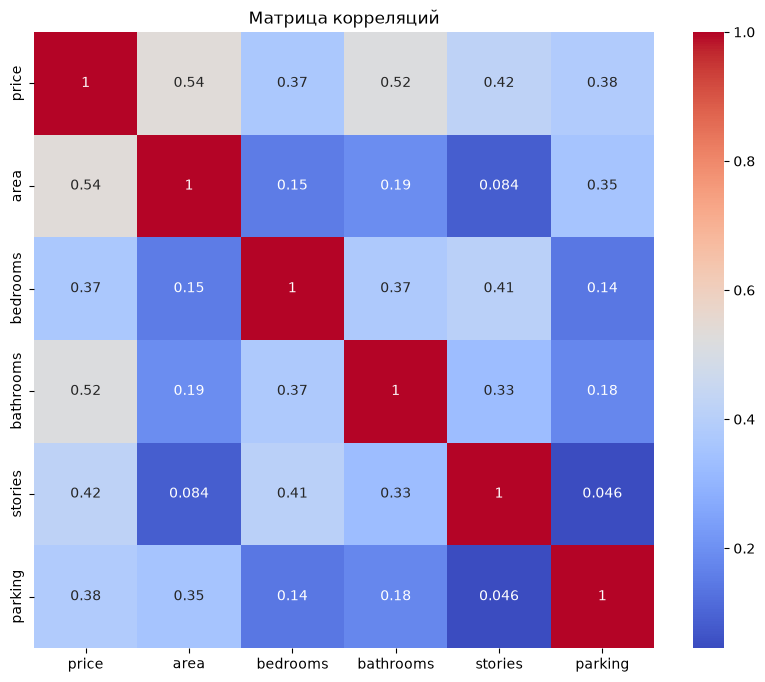

In [2]:
import seaborn as sns
import matplotlib.pyplot as plt

correlation_matrix = df.corr(numeric_only=True)

plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm")
plt.title("Матрица корреляций")
plt.show()

---
### 3. Постройте матрицу диаграмм рассеяния.

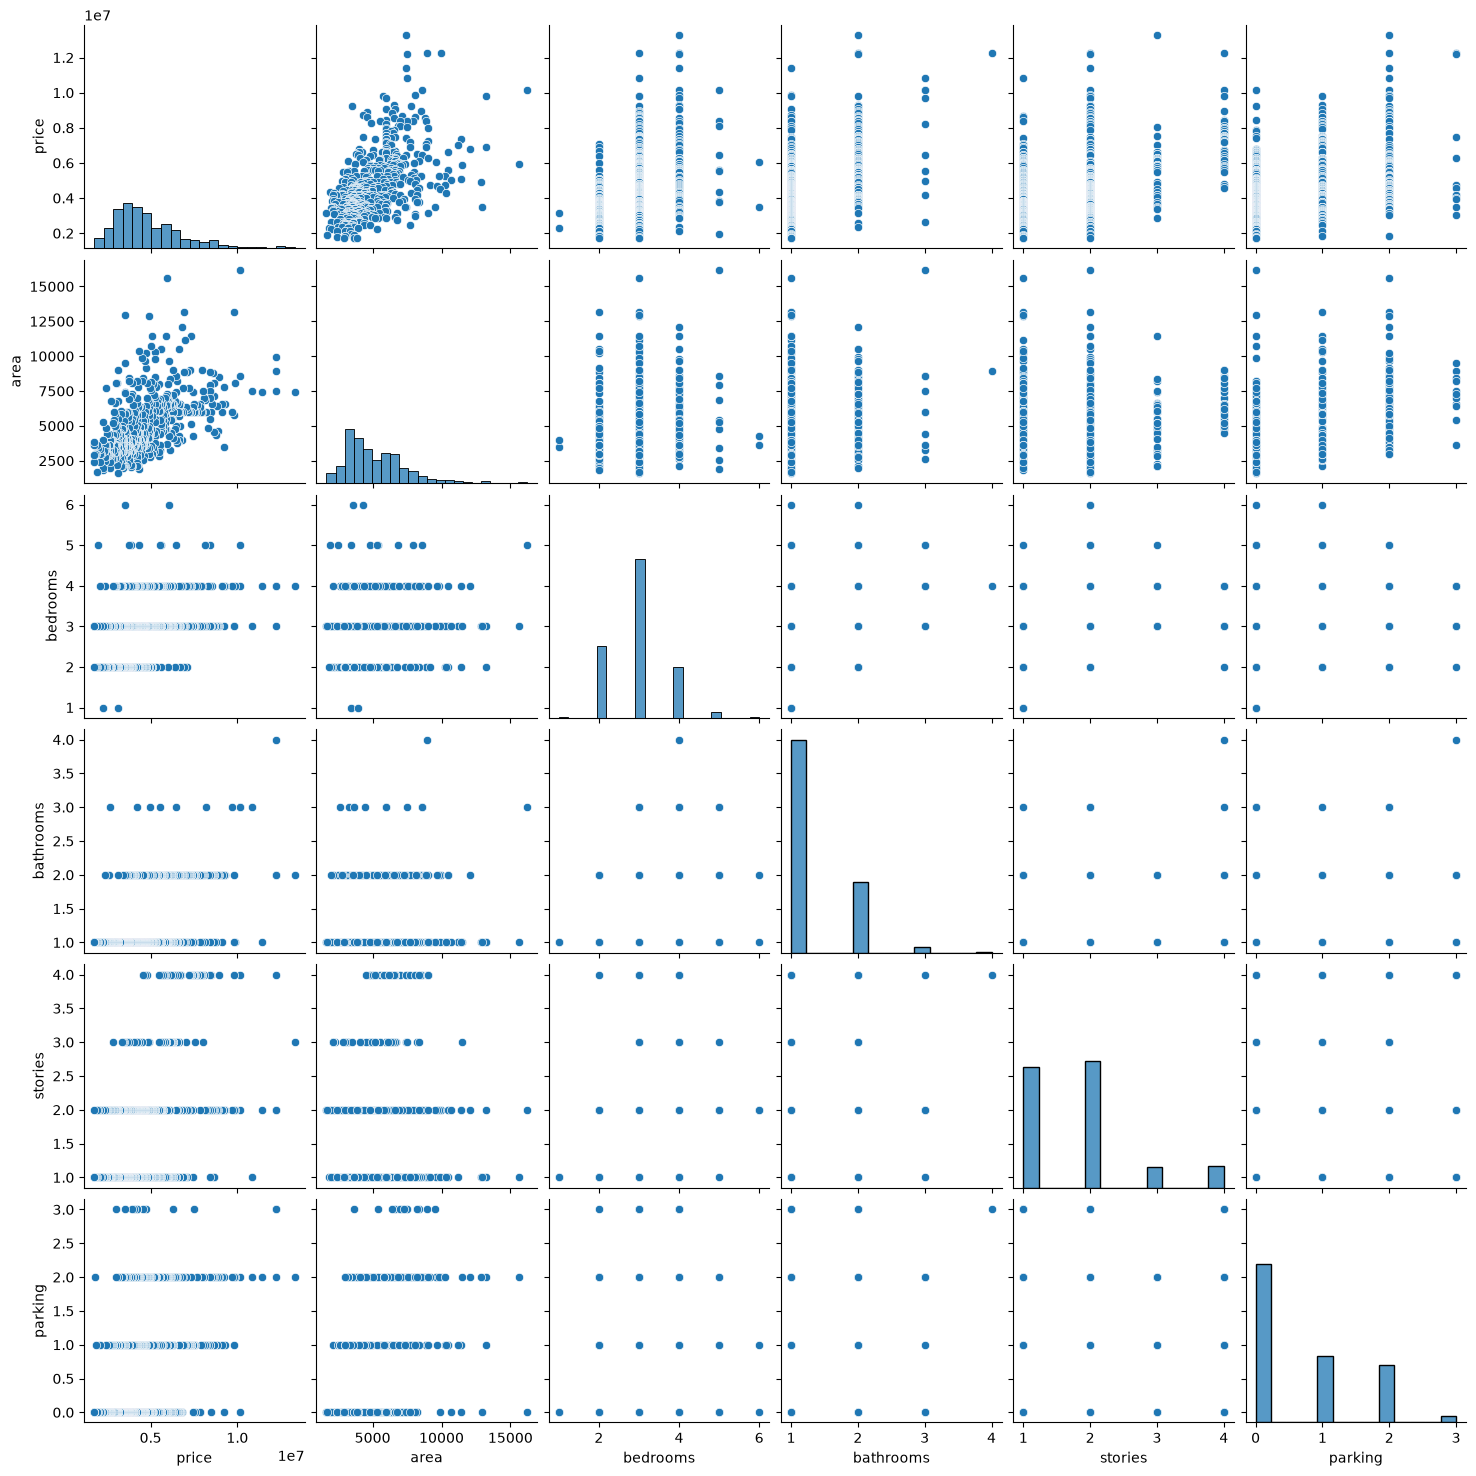

In [3]:
sns.pairplot(df.select_dtypes(include="number"))
plt.show()

---
### 4. Проанализируйте коэффициенты корреляции и диаграммы рассеяния и выберите параметры для построения модели простой линейной регрессии.

price x area

---
### 5. Рассчитайте модель и визуализируйте график модели на диаграмме рассеяния параметра (который учтен в модели)

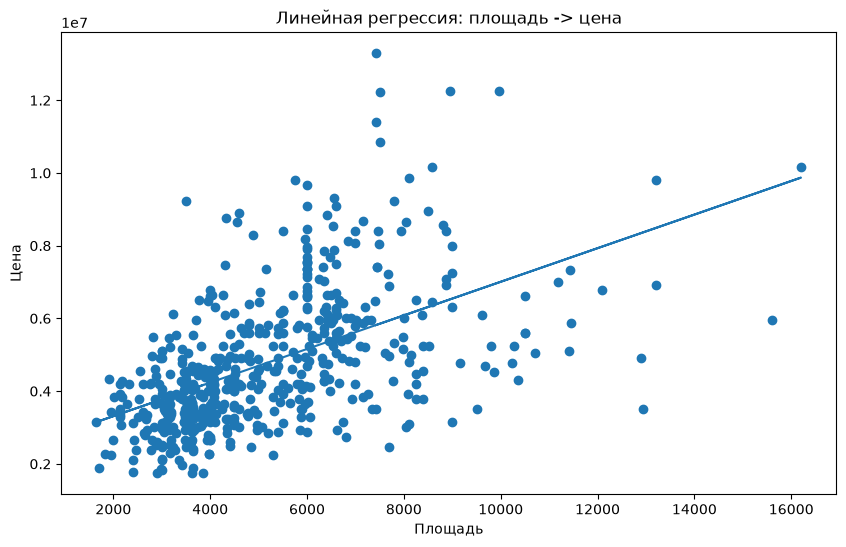

Коэффициент: 461.97489427278344
Свободный член: 2387308.48239643


In [4]:
from sklearn.linear_model import LinearRegression

X = df[["area"]]
y = df["price"]

model = LinearRegression()
model.fit(X, y)

y_pred = model.predict(X)

plt.figure(figsize=(10, 6))
plt.scatter(X, y)
plt.plot(X, y_pred)
plt.xlabel("Площадь")
plt.ylabel("Цена")
plt.title("Линейная регрессия: площадь -> цена")
plt.show()

print("Коэффициент:", model.coef_[0])
print("Свободный член:", model.intercept_)

---
### 6. Оцените качество полученной модели, рассчитайте коэффициент детерминации.

In [5]:
from sklearn.metrics import r2_score

r2 = r2_score(y, y_pred)

print("Коэффициент детерминации R²:", r2)

Коэффициент детерминации R²: 0.2872931546811469


---
### 7. Добавьте в модель линейной регрессии еще несколько параметров, в той или иной мере влияющих на целевую переменную.

In [6]:
X_multi = df[["area", "bedrooms", "bathrooms", "stories", "parking"]]
y = df["price"]

model_multi = LinearRegression()
model_multi.fit(X_multi, y)

y_pred_multi = model_multi.predict(X_multi)

---
### 8. Рассчитайте модель с несколькими параметрами и оцените качество модели.

In [7]:
r2_multi = r2_score(y, y_pred_multi)
print("R² множественной модели:", r2_multi)

R² множественной модели: 0.5615825438679802


---
### 9. Сделайте вывод: какая модель лучше описывает зависимость целевой переменной от параметров.

Простая линейная регрессия с одним параметром area имеет коэффициент детерминации ($R^2 = 0.2873$), то есть объясняет около 28.73% вариации цены. Множественная линейная регрессия имеет ($R^2 = 0.5616$) и объясняет около 56.16% вариации цены. Следовательно, множественная модель лучше описывает зависимость цены дома от его параметров, поскольку учитывает больше факторов и имеет более высокий коэффициент детерминации.